# <center>Organizaci&oacute;n de Datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Clasificación de textos</center>
### <center> Naive Bayes y SentiWordNet </center>


# Referencias:

- Curso Text Mining de la Maestría de Data Mining, Facultad de Ciencia Exactas y Naturales de la Universidad de Buenos Aires (FCEyN - UBA). Clase de Clasificacion de textos con Naive Bayes.  
- [Data Camp tutorial: NLTK Sentiment Analysis Tutorial for Beginners](https://www.datacamp.com/tutorial/text-analytics-beginners-nltk?utm_source=google&utm_medium=paid_search&utm_campaignid=21057859163&utm_adgroupid=157296744657&utm_device=c&utm_keyword=&utm_matchtype=&utm_network=g&utm_adpostion=&utm_creative=698229405991&utm_targetid=dsa-2218886984100&utm_loc_interest_ms=&utm_loc_physical_ms=1000073&utm_content=&utm_campaign=230119_1-sea~dsa~tofu_2-b2c_3-es-lang-en_4-prc_5-na_6-na_7-le_8-pdsh-go_9-na_10-na_11-na-may24&gad_source=1&gclid=CjwKCAjwr7ayBhAPEiwA6EIGxFb-XBS4jfd-tyxSQOGIervg_8i12xeN27wFScvDfp1kU00ErMunSRoCcPoQAvD_BwE)

# Importaciones

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
import random

from nltk import word_tokenize, sent_tokenize

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV,StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.dummy import DummyClassifier
import nltk
nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('sentiwordnet')
from nltk.corpus import stopwords
from nltk.corpus import movie_reviews
from nltk.corpus import sentiwordnet as swn
from nltk.corpus import wordnet as wn


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package sentiwordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/sentiwordnet.zip.


# Exploración de los datos



In [2]:
movie_reviews.categories()

['neg', 'pos']

In [3]:
neg_review_fileids = movie_reviews.fileids('neg')
neg_review_fileids[:10]

['neg/cv000_29416.txt',
 'neg/cv001_19502.txt',
 'neg/cv002_17424.txt',
 'neg/cv003_12683.txt',
 'neg/cv004_12641.txt',
 'neg/cv005_29357.txt',
 'neg/cv006_17022.txt',
 'neg/cv007_4992.txt',
 'neg/cv008_29326.txt',
 'neg/cv009_29417.txt']

In [4]:
print(movie_reviews.raw(neg_review_fileids[2]))

it is movies like these that make a jaded movie viewer thankful for the invention of the timex indiglo watch . 
based on the late 1960's television show by the same name , the mod squad tells the tale of three reformed criminals under the employ of the police to go undercover . 
however , things go wrong as evidence gets stolen and they are immediately under suspicion . 
of course , the ads make it seem like so much more . 
quick cuts , cool music , claire dane's nice hair and cute outfits , car chases , stuff blowing up , and the like . 
sounds like a cool movie , does it not ? 
after the first fifteen minutes , it quickly becomes apparent that it is not . 
the mod squad is certainly a slick looking production , complete with nice hair and costumes , but that simply isn't enough . 
the film is best described as a cross between an hour-long cop show and a music video , both stretched out into the span of an hour and a half . 
and with it comes every single clich ? . 
it doesn't really 

In [5]:
documents = []

for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        documents.append((movie_reviews.raw(fileid), category))

df = pd.DataFrame(documents, columns=['review', 'tag'])


In [6]:
df = df.sample(frac=1,random_state=0).reset_index(drop=True).copy()
df.head()

,review,tag
0,arnold schwarzenegger has been an icon for act...,neg
1,good films are hard to find these days . \ngre...,pos
2,quaid stars as a man who has taken up the prof...,pos
3,we could paraphrase michelle pfieffer's charac...,neg
4,kolya is one of the richest films i've seen in...,pos


In [7]:
df.tag.value_counts()

tag
neg    1000
pos    1000
Name: count, dtype: int64

## Generación de conjuntos de train y test

In [8]:
train_test_split?

In [9]:
# separamos entre train y test sets
X = df.review
y = df.tag
X_train_text, X_test_text, y_train, y_test = train_test_split(X,y,
                                                              stratify=y,
                                                              test_size=0.20,
                                                              random_state=1234)

In [10]:
y_train.value_counts()

tag
neg    800
pos    800
Name: count, dtype: int64

In [11]:
y_test.value_counts()

tag
neg    200
pos    200
Name: count, dtype: int64

## Veamos un poco los textos

In [12]:
X_train_text.tolist()[:5]

['wolfgang petersen\'s latest , the perfect storm , is like a pineapple . \nit only tastes good after arduous peeling and digging - if you try to eat the fruit , spikes and all , it\'s going to hurt ? quite a bit . \nok , maybe that was a confusing analogy , so here\'s my main complaint about the latest man battles nature flick : there isn\'t really much of a story to tell . \nbasically , a massachusetts fishing crew goes out to sea on a small boat , called the andrea gail , and gets stuck in the middle of " the storm of the century . " \nhow much time does it take for petersen to tell this story ? \nnot nearly enough . \nso he spends the majority of the film developing pointless side stories which all eventually become superfluous . \naudiences want to see the storm , they want to see a fight for survival but what they get is a lot of cliched , maudlin drivel . \nthe last quarter of the perfect storm is utterly perfect in every aspect , but just try lasting the first three-quarters . 

## Puedo definir una funcion para limpiar el texto y otra para tokenizar


In [13]:
# En este caso particular no hace falta limpiar los textos
def clean_text(text):
  return text.strip()

In [14]:
def tokenizer(text):
    #return [w for w in word_tokenize(text) if w.isalpha()] # si solo nos interesan palabras
    return word_tokenize(text)
tokenizer(clean_text(X_train_text.iloc[1]))[:10]

['i',
 'have',
 'to',
 'admit',
 'that',
 'i',
 'disliked',
 'this',
 'film',
 'initially']

## Puedo definir un stoplist


In [15]:
stoplist = stopwords.words("english")

In [16]:
stoplist[:15]

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours']

In [17]:
# tokenizo el stoplist con el mismo tokenizar que voy a usar en el corpus
stoplist_tokenized = []
for w in stoplist:
    stoplist_tokenized = stoplist_tokenized + tokenizer(w)

In [18]:
stoplist_tokenized[:15]

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 'you',
 "'re",
 'you',
 "'ve",
 'you',
 "'ll"]

In [19]:
# Armo una lista sin repeticiones
stoplist_tokenized = list(set(stoplist_tokenized))

## Extraigo Features

In [20]:
count_vect = CountVectorizer(preprocessor=clean_text,
                             tokenizer=tokenizer,
                             min_df=5,
                             stop_words=stoplist_tokenized)
X_train = count_vect.fit_transform(X_train_text) # cuenta frecuencia de tokens y define el diccionario
X_test = count_vect.transform(X_test_text) # cuenta frecuencia de tokens existentes en el diccionario
X_train

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


<1600x11646 sparse matrix of type '<class 'numpy.int64'>'
	with 390555 stored elements in Compressed Sparse Row format>

In [21]:
shape = X_train.shape
total_elements = shape[0] * shape[1]

print("Matrix shape:", shape)
print("Matrix size:", total_elements)


Matrix shape: (1600, 11646)
Matrix size: 18633600


In [22]:
non_zero_elements = X_train.nnz  # nnz es el número de elementos distintos de cero
percentage_non_zero = (non_zero_elements / total_elements) * 100


print("Percentage of non-zero elements:", percentage_non_zero, "%")


Percentage of non-zero elements: 2.095971792890263 %


In [23]:
# Vocabulario
vocab = count_vect.vocabulary_

# Obtener las primeras 20 palabras del vocabulario
print(list(vocab.keys())[:20])

['wolfgang', 'latest', ',', 'perfect', 'storm', 'like', '.', 'tastes', 'good', 'digging', '-', 'try', 'eat', 'fruit', 'going', 'hurt', '?', 'quite', 'bit', 'ok']


In [24]:
count_vect.get_feature_names_out()[:20]

array(['!', '#', '$', '%', '&', "'", "''", "'60s", "'70s", "'80s", "'90s",
       "'97", "'cause", "'em", "'m", "'n", "'the", '(', ')', '*'],
      dtype=object)

# Naive Bayes

In [25]:
clf = MultinomialNB(alpha=1) # alpha es el smoothing parameter
scores_cv_nb = cross_val_score(clf,
                               X_train, y_train,
                               cv = 10, scoring='f1_macro')
scores_cv_nb


array([0.79987492, 0.84300797, 0.81857283, 0.86230637, 0.8437439 ,
       0.74964794, 0.82431373, 0.81874292, 0.79354839, 0.8125    ])

In [26]:
print("f-score=",round(scores_cv_nb.mean(),4)," ( sd =",round(scores_cv_nb.std(),4),")")

f-score= 0.8166  ( sd = 0.0298 )


### Dummy

In [27]:
clf_dummy = DummyClassifier(strategy="stratified")
scores_dummy_cv = cross_val_score(clf_dummy,X_train, y_train,cv = 10, scoring='f1_macro')
print("f-score=",round(scores_dummy_cv.mean(),4)," ( sd =",round(scores_cv_nb.std(),4),")\n")

f-score= 0.4795  ( sd = 0.0298 )



## N-gramas

In [28]:
# incluyo bigramas (aclaracion:si aparece "best friend" tambien va a contar para "best" y para "friend")
count_vect = CountVectorizer(preprocessor=clean_text,
                             tokenizer=tokenizer,
                             min_df=5,
                             stop_words=stoplist_tokenized,
                             ngram_range=(1,2))
X_train_ngrams = count_vect.fit_transform(X_train_text) # cuenta frecuencia de tokens y define el diccionario
print("numero de features=",X_train_ngrams.shape[1])

scores_cv_ngrams = cross_val_score(clf,X_train_ngrams, y_train,cv = 10, scoring='f1_macro')
print("f-score=",round(scores_cv_ngrams.mean(),4)," ( sd =",round(scores_cv_ngrams.std(),4),")")

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


numero de features= 26885
f-score= 0.8149  ( sd = 0.0261 )


In [29]:
count_vect.get_feature_names_out()[:20]

array(['!', '! !', "! '", "! 'm", '! (', '! )', '! *', '! ,', '! .',
       '! ?', '! ``', '! also', '! even', '! film', '! joblo', '! know',
       '! like', '! movie', '! oh', '! one'], dtype=object)

### Pruebo otros parametros

In [30]:
count_vect = CountVectorizer(preprocessor=clean_text,
                             tokenizer=tokenizer,
                             min_df=30, #modifico el limite de n-values para que un n-grams sea considerado
                             stop_words=stoplist_tokenized,
                             ngram_range=(1,2))

X_train_ngrams = count_vect.fit_transform(X_train_text) # cuenta frecuencia de tokens y define el diccionario
print("numero de features =",X_train_ngrams.shape[1])

clf = MultinomialNB(alpha=1)
scores_cv_ngrams_v2 = cross_val_score(clf,X_train_ngrams, y_train,cv = 10, scoring='f1_macro')
print("f-score =",round(scores_cv_ngrams_v2.mean(),4)," ( sd =",round(scores_cv_ngrams_v2.std(),4),")")

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


numero de features = 3850
f-score = 0.8142  ( sd = 0.0222 )


## Selecciono el mejor modelo

In [31]:
pd.Series({'NB (min_df=5)':round(scores_cv_nb.mean(),3),
           'NB with ngrams (min_df=5)':round(scores_cv_ngrams.mean(),3),
           'NB with ngrams (min_df=30)':round(scores_cv_ngrams_v2.mean(),3)})

NB (min_df=5)                 0.817
NB with ngrams (min_df=5)     0.815
NB with ngrams (min_df=30)    0.814
dtype: float64

In [32]:
count_vect = CountVectorizer(preprocessor=clean_text,
                             tokenizer=tokenizer,
                             min_df=5,
                             stop_words=stoplist_tokenized,
                             ngram_range=(1,1))

X_train_ngrams = count_vect.fit_transform(X_train_text) # cuenta frecuencia de tokens y define el diccionario
X_test_ngrams = count_vect.transform(X_test_text) # cuenta frecuencia de tokens existentes en el diccionario
print("numero de features=",X_train_ngrams.shape[1])

# entreno el clasificador
clf = MultinomialNB(alpha=1).fit(X_train_ngrams, y_train)

# predigo en el set de testeo
y_pred = clf.predict(X_test_ngrams)
scores_ngrams = pd.Series(precision_recall_fscore_support(y_test, y_pred,average="macro")[:3],
                          index=["precision","recall","fscore"])
print("\nNgrams\n")
print(scores_ngrams)
print("\nNmatriz de confusión\n",confusion_matrix(y_test, y_pred))



/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


numero de features= 11646

Ngrams

precision    0.816138
recall       0.815000
fscore       0.814833
dtype: float64

Nmatriz de confusión
 [[169  31]
 [ 43 157]]


# Normalizacion

##  Stemming


In [33]:
# Stemizacion: lleva una palabra a su raíz (la cual puede no ser una palabra)
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer("english")
stemmer.stem("explanation")

'explan'

In [34]:
[(w,stemmer.stem(w)) for w in word_tokenize(clean_text(X_train_text.iloc[0])) if w.isalpha()][:50]

[('wolfgang', 'wolfgang'),
 ('petersen', 'petersen'),
 ('latest', 'latest'),
 ('the', 'the'),
 ('perfect', 'perfect'),
 ('storm', 'storm'),
 ('is', 'is'),
 ('like', 'like'),
 ('a', 'a'),
 ('pineapple', 'pineappl'),
 ('it', 'it'),
 ('only', 'onli'),
 ('tastes', 'tast'),
 ('good', 'good'),
 ('after', 'after'),
 ('arduous', 'arduous'),
 ('peeling', 'peel'),
 ('and', 'and'),
 ('digging', 'dig'),
 ('if', 'if'),
 ('you', 'you'),
 ('try', 'tri'),
 ('to', 'to'),
 ('eat', 'eat'),
 ('the', 'the'),
 ('fruit', 'fruit'),
 ('spikes', 'spike'),
 ('and', 'and'),
 ('all', 'all'),
 ('it', 'it'),
 ('going', 'go'),
 ('to', 'to'),
 ('hurt', 'hurt'),
 ('quite', 'quit'),
 ('a', 'a'),
 ('bit', 'bit'),
 ('ok', 'ok'),
 ('maybe', 'mayb'),
 ('that', 'that'),
 ('was', 'was'),
 ('a', 'a'),
 ('confusing', 'confus'),
 ('analogy', 'analog'),
 ('so', 'so'),
 ('here', 'here'),
 ('my', 'my'),
 ('main', 'main'),
 ('complaint', 'complaint'),
 ('about', 'about'),
 ('the', 'the')]

#### Cuidado!
Notar que "empathy" y "empathize" no van a la misma raiz!

In [35]:
print(stemmer.stem("empathy"))
print(stemmer.stem("empathize"))

empathi
empath


## Lematizacion

In [36]:
# Lematizacion: lleva una palabra a su forma canónica
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
wnl = WordNetLemmatizer()

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [37]:
# para lemmatizar es necesario dar la categoria gramatical(part-of-speach)
# los POS validos son ("a","v","n","r")(adjetivo,verbo,sustantivo,advervio)
wnl.lemmatize(word="was",pos="v")

'be'

In [38]:
postags = pos_tag(word_tokenize(clean_text(X_train_text.iloc[1])))
postags[:20]

[('i', 'NNS'),
 ('have', 'VBP'),
 ('to', 'TO'),
 ('admit', 'VB'),
 ('that', 'IN'),
 ('i', 'NN'),
 ('disliked', 'VBD'),
 ('this', 'DT'),
 ('film', 'NN'),
 ('initially', 'RB'),
 ('.', '.'),
 ('it', 'PRP'),
 ('certianly', 'RB'),
 ('is', 'VBZ'),
 ("n't", 'RB'),
 ('for', 'IN'),
 ('every', 'DT'),
 ('taste', 'NN'),
 (',', ','),
 ('and', 'CC')]

In [39]:
def word_pos_to_lemma(word,pos,wnl):
    if pos.startswith('J'):
        return wnl.lemmatize(word,wordnet.ADJ) # adjetivo
    elif pos.startswith('V'):
        return wnl.lemmatize(word,wordnet.VERB) # vervo
    elif pos.startswith('N'):
        return wnl.lemmatize(word,wordnet.NOUN)# sustantivo
    elif pos.startswith('R'):
        return wnl.lemmatize(word,wordnet.ADV) # advervio
    else:
        return wnl.lemmatize(word)

In [40]:
[(w,word_pos_to_lemma(w,pos,wnl) ) for w,pos in postags if w.isalpha()][:25]

[('i', 'i'),
 ('have', 'have'),
 ('to', 'to'),
 ('admit', 'admit'),
 ('that', 'that'),
 ('i', 'i'),
 ('disliked', 'dislike'),
 ('this', 'this'),
 ('film', 'film'),
 ('initially', 'initially'),
 ('it', 'it'),
 ('certianly', 'certianly'),
 ('is', 'be'),
 ('for', 'for'),
 ('every', 'every'),
 ('taste', 'taste'),
 ('and', 'and'),
 ('it', 'it'),
 ('sheer', 'sheer'),
 ('torture', 'torture'),
 ('to', 'to'),
 ('sit', 'sit'),
 ('through', 'through'),
 ('if', 'if'),
 ('you', 'you')]

TODO: aplicar la lematizacion al corpus y analizar si mejora la performance de Naive Bayes

# SentiWordNet

SentiWordNet es un recurso léxico que asigna puntajes de sentimiento (positivo, negativo y neutral) a conjuntos de sinónimos (synsets) del WordNet de Princeton. WordNet es una base de datos léxica en inglés donde las palabras se agrupan en conjuntos de sinónimos (synsets) que representan conceptos diferentes. Por ejemplo, el synset {boy, child, young man} representa un concepto diferente al synset {book, volume, notebook}.


SentiWordNet complementa a WordNet al asignar puntajes numéricos que indican la polaridad de sentimiento de cada synset. Estos puntajes son:

1.   Puntaje Positivo: Indica cuán positivo es el sentimiento del synset (entre 0 y 1).
2.  Puntaje Negativo: Indica cuán negativo es el sentimiento del synset (entre 0 y 1).
3. Puntaje Objetivo: Indica cuán objetivo u neutral es el sentimiento del synset (entre 0 y 1).

La suma de los tres puntajes para un synset siempre es 1.


In [45]:
# Ejemplo: obtener puntajes de sentimiento para la palabra 'awful'
word = wn.synsets('awful')[0] # Obtenemos el primer synset de 'awful'
sentiment_scores = swn.senti_synset(word.name()) # Obtenemos los puntajes de sentimiento

print(f"Palabra: {word.name()}")
print(f"Scores: {sentiment_scores}")
print(f"Puntaje Positivo: {sentiment_scores.pos_score()}")
print(f"Puntaje Negativo: {sentiment_scores.neg_score()}")
print(f"Puntaje Objetivo: {sentiment_scores.obj_score()}")

Palabra: atrocious.s.02
Scores: <atrocious.s.02: PosScore=0.0 NegScore=0.875>
Puntaje Positivo: 0.0
Puntaje Negativo: 0.875
Puntaje Objetivo: 0.125


In [ ]:
def penn_to_wn(tag):
    """
    Convert between the PennTreebank tags to simple Wordnet tags
    """
    if tag.startswith('J'):
        return wn.ADJ
    elif tag.startswith('N'):
        return wn.NOUN
    elif tag.startswith('R'):
        return wn.ADV
    elif tag.startswith('V'):
        return wn.VERB
    return None


def get_word_sentiment(word , wn_tag_bool=False):
    """
    Función para obtener el puntaje de sentimiento de una palabra
    """
    if wn_tag_bool:
      wn_tag = penn_to_wn(word)
      if wn_tag not in (wn.NOUN, wn.ADJ, wn.ADV):
          return []

    sentiment_scores = list(swn.senti_synsets(word, pos=wn_tag))  if wn_tag_bool else list(swn.senti_synsets(word))
    if sentiment_scores:
        return sentiment_scores[0]
    else:
        return None

def get_score(sentence, method='avg'):
    """
    Función para clasificar una oración como positiva o negativa
    """
    words = nltk.word_tokenize(sentence)
    pos_scores = []
    neg_scores = []
    for word in words:
        sentiment = get_word_sentiment(word)
        # print(f'word: {word} \t sentiment: {sentiment}')
        if sentiment:
            pos_scores.append(sentiment.pos_score())
            neg_scores.append(sentiment.neg_score())

    if method == 'avg':
      pos_score = sum(pos_scores) / len(pos_scores) if pos_scores else 0
      neg_score = sum(neg_scores) / len(neg_scores) if neg_scores else 0
    elif method == 'sum':
      pos_score = sum(pos_scores)  if pos_scores else 0
      neg_score = sum(neg_scores)  if neg_scores else 0

    return pos_score - neg_score

def classify_sentence(score, threshold=0.5):
  if score >= threshold:
        return 'pos'
  else:
        return 'neg'


In [ ]:
def make_prediction(X_to_predict, method='avg', threshold=0.5 ):
  """
  Clasifica los datos
  """
  y_scores = []
  y_predict = []
  for sentence in X_to_predict:
      score = get_score(sentence, method)
      label = classify_sentence(score, threshold )
      y_scores.append(score)
      y_predict.append(label)

  return y_predict, y_scores


In [ ]:
def get_metrics(y_predict, y_ground_truth):
    """
    Evaluar en los datos de prueba
    """
    correct = 0
    total = 0
    true_positive = 0
    false_positive = 0
    false_negative = 0

    for predicted_label, true_label in zip(y_predict, y_ground_truth):
        if predicted_label == true_label:
            correct += 1
            if predicted_label == 'pos':  # Assuming binary classification with labels 0 and 1
                true_positive += 1
        else:
            if predicted_label == 'pos':
                false_positive += 1
            if true_label == 'pos':
                false_negative += 1
        total += 1

    accuracy = correct / total

    if true_positive + false_positive > 0:
        precision = true_positive / (true_positive + false_positive)
    else:
        precision = 0

    if true_positive + false_negative > 0:
        recall = true_positive / (true_positive + false_negative)
    else:
        recall = 0

    if precision + recall > 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0

    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall: {recall*100:.2f}%")
    print(f"F1 Score: {f1_score*100:.2f}%")

In [ ]:
y_train_predict, y_train_scores = make_prediction(X_train_text, method='sum', threshold=10)
y_test_predict, y_test_scores = make_prediction(X_test_text, method='sum', threshold=10)

In [ ]:
for index, (score , predict) in enumerate(zip (y_test_scores, y_test_predict)):
  print(f'score: {round(score)} \t predict: {predict} ')
  if index == 9:
    break

score: 1 	 predict: neg 
score: 4 	 predict: neg 
score: 22 	 predict: pos 
score: -1 	 predict: neg 
score: 8 	 predict: neg 
score: 4 	 predict: neg 
score: -6 	 predict: neg 
score: 11 	 predict: pos 
score: -10 	 predict: neg 
score: 1 	 predict: neg 


In [ ]:
print(pd.Series(y_train_predict).value_counts())
get_metrics(y_train_predict, y_train)

neg    1289
pos     311
Name: count, dtype: int64
Accuracy: 61.19%
Precision: 78.78%
Recall: 30.63%
F1 Score: 44.10%


In [ ]:
print(pd.Series(y_test_predict).value_counts())
get_metrics(y_test_predict, y_test)

neg    330
pos     70
Name: count, dtype: int64
Accuracy: 61.00%
Precision: 81.43%
Recall: 28.50%
F1 Score: 42.22%


In [ ]:
# Evaluar con precision_recall_fscore_support y confusion_matrix
labels = ['pos', 'neg']
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_test_predict,
                                                               labels=labels, average=None)
conf_matrix = confusion_matrix(y_test, y_test_predict, labels=labels)

print("Precision:")
for label, p in zip(labels, precision):
    print(f"{label}: {p:.2f}")

print("\nRecall:")
for label, r in zip(labels, recall):
    print(f"{label}: {r:.2f}")

print("\nF-score:")
for label, f in zip(labels, fscore):
    print(f"{label}: {f:.2f}")

print("\nConfusion Matrix:")
print(conf_matrix)

Precision:
pos: 0.81
neg: 0.57

Recall:
pos: 0.28
neg: 0.94

F-score:
pos: 0.42
neg: 0.71

Confusion Matrix:
[[ 57 143]
 [ 13 187]]


# Zipf's Law

La frecuencia de cualquier palabra es inversamente proporcional a su rango en la tabla de frecuencias.

In [ ]:
# Series con todas las palabras del corpus
words_series = pd.Series([word for rev in df.review for word in word_tokenize(rev) if word.isalpha()])

In [ ]:
# Frecuencia de cada palabra en el corpus
word_freq = words_series.value_counts()
word_freq

the             76276
a               37995
and             35404
of              33972
to              31772
                ...  
martyrs             1
unintriguing        1
prefixed            1
possessive          1
sutra               1
Name: count, Length: 38107, dtype: int64

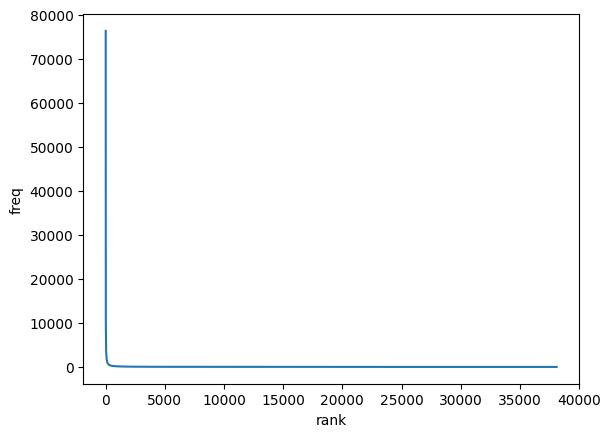

In [ ]:
# plot de frecuencia vs ranking (la palabra mas frecuente tiene rank=1, la segunda tiene rank=2, etc..)
plt.plot(range(len(word_freq)),word_freq)
plt.xlabel('rank');plt.ylabel('freq');


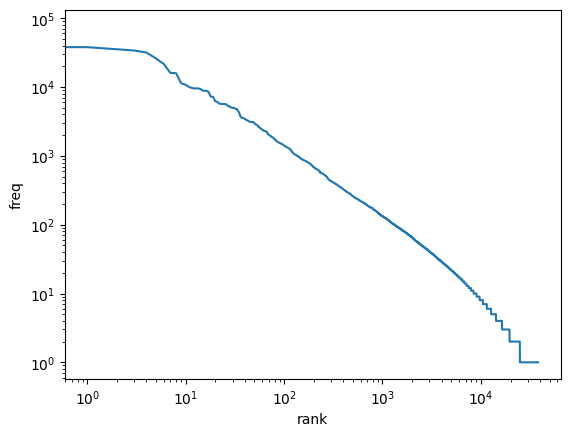

In [ ]:
# ahora en eje logaritmico
plt.plot(range(len(word_freq)),word_freq)
plt.xlabel('rank');plt.ylabel('freq')
plt.xscale('log'); plt.yscale('log');


In [ ]:
# palabras con 1 sola occurrencia
print("el ",
      round(100*sum(word_freq==1)/len(word_freq),2),
      "% de las palabras aparecen 1 sola vez")

el  34.82 % de las palabras aparecen 1 sola vez


In [ ]:
print("las 10 palabras mas frecuentes representan el ",
      round(100*word_freq[:10].sum()/word_freq.sum(),2),
      "% del corpus")

las 10 palabras mas frecuentes representan el  24.05 % del corpus
